In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/matches - matches.csv")
df.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [5]:
df1 = pd.read_csv("/content/drive/MyDrive/Datasets/deliveries.csv")
df1.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


**1. Who are the top 10 batsmen based on total runs?**

  **Logic :**
  
  Group by batsman → sum runs → sort → top 10

batsman
V Kohli           5434
SK Raina          5415
RG Sharma         4914
DA Warner         4741
S Dhawan          4632
CH Gayle          4560
MS Dhoni          4477
RV Uthappa        4446
AB de Villiers    4428
G Gambhir         4223
Name: batsman_runs, dtype: int64


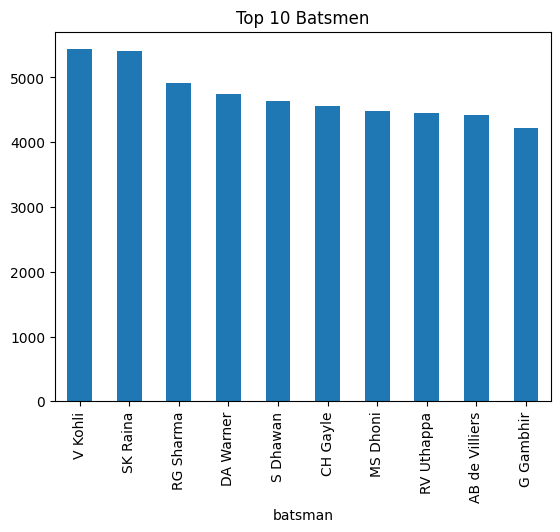

In [ ]:
top_batsmen = df1.groupby('batsman')['batsman_runs'].sum()
top_batsmen = top_batsmen.sort_values(ascending=False).head(10)

print(top_batsmen)

top_batsmen.plot(kind='bar', title='Top 10 Batsmen')
plt.show()

**2. Who are the top 10 bowlers based on wickets taken?**

**Logic:**

Filter rows where wicket happened → count per bowler

bowler
SL Malinga         188
DJ Bravo           168
A Mishra           165
Harbhajan Singh    161
PP Chawla          156
B Kumar            141
R Ashwin           138
SP Narine          137
UT Yadav           136
R Vinay Kumar      127
Name: count, dtype: int64


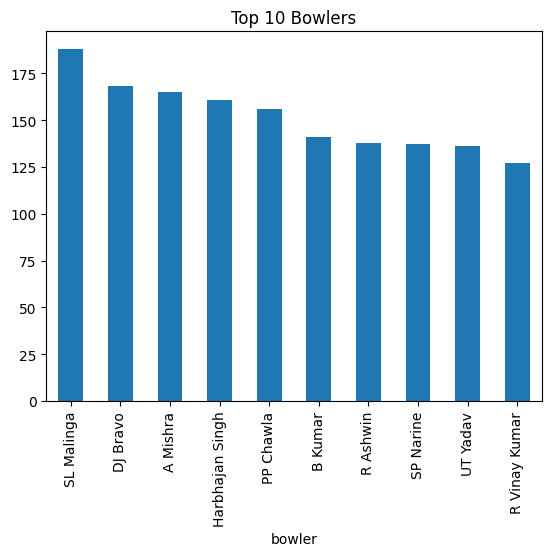

In [ ]:
wickets = df1[df1['dismissal_kind'].notnull()]
top_bowlers = wickets['bowler'].value_counts().head(10)

print(top_bowlers)

top_bowlers.plot(kind='bar', title='Top 10 Bowlers')
plt.show()

**3. Which teams have won the most matches?**

winner
Mumbai Indians                 92
Chennai Super Kings            79
Kolkata Knight Riders          77
Royal Challengers Bangalore    73
Kings XI Punjab                70
Rajasthan Royals               63
Delhi Daredevils               62
Sunrisers Hyderabad            42
Deccan Chargers                29
Gujarat Lions                  13
Name: count, dtype: int64


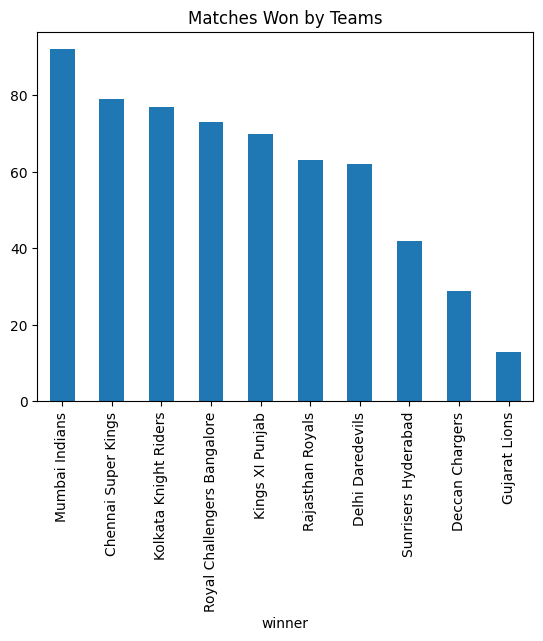

In [ ]:
team_wins = df['winner'].value_counts().head(10)

print(team_wins)

team_wins.plot(kind='bar', title='Matches Won by Teams')
plt.show()

**4. Does winning the toss affect the match result?**

**Logic:**

Check when toss_winner == match winner

In [ ]:
toss_win = df[df['toss_winner'] == df['winner']]

percentage = (len(toss_win) / len(df)) * 100

print("Win % after winning toss:", percentage)

Win % after winning toss: 51.100628930817614


**5. What is the distribution of runs scored in matches?**

**Logic:**

Total runs per match → histogram

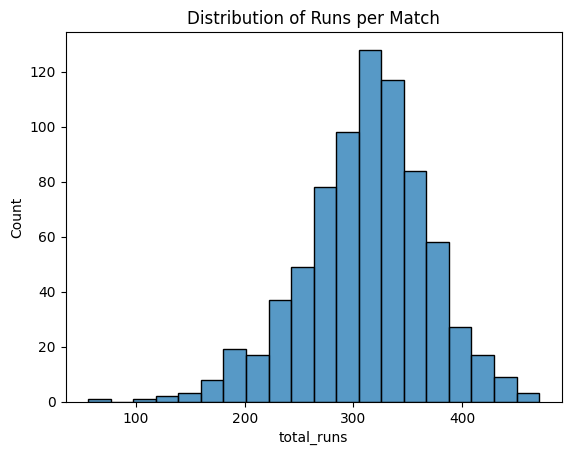

In [ ]:
total_runs = df1.groupby('match_id')['total_runs'].sum()

sns.histplot(total_runs, bins=20)
plt.title("Distribution of Runs per Match")
plt.show()

**6. Which venues are high scoring?**

**Logic:**

Get total runs per match from deliveries

Merge with matches to get venue

Calculate average runs per venue

venue
Brabourne Stadium                                       349.272727
Saurashtra Cricket Association Stadium                  333.300000
Barabati Stadium                                        325.428571
Green Park                                              324.500000
Punjab Cricket Association IS Bindra Stadium, Mohali    322.272727
Himachal Pradesh Cricket Association Stadium            321.888889
MA Chidambaram Stadium, Chepauk                         318.270833
Maharashtra Cricket Association Stadium                 317.466667
Wankhede Stadium                                        315.631579
Holkar Cricket Stadium                                  315.200000
Name: total_runs, dtype: float64


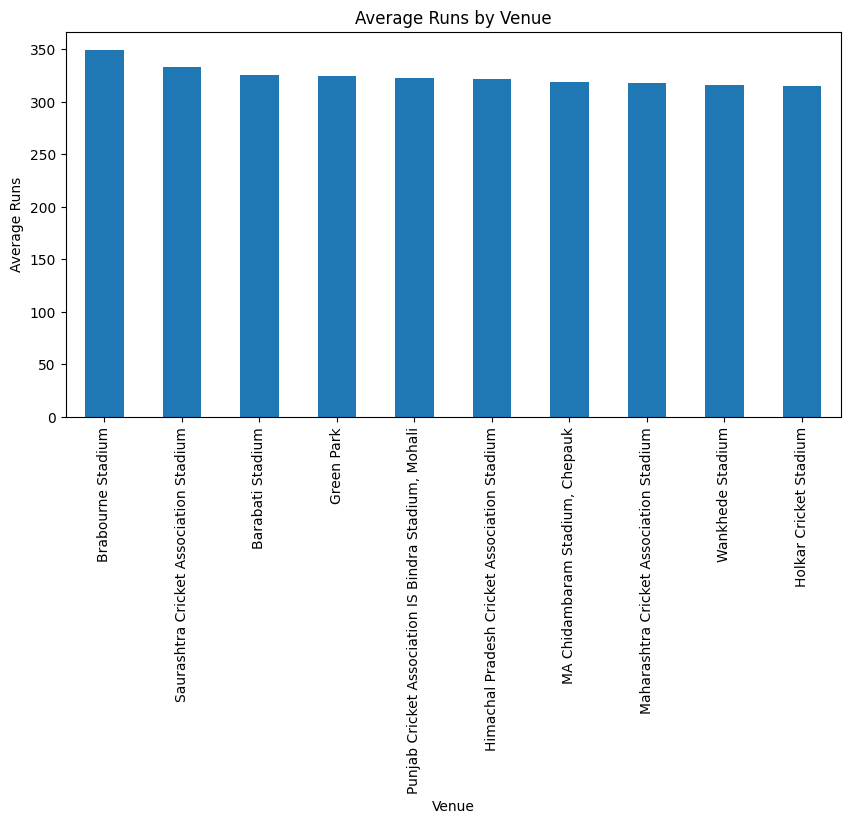

In [12]:
# Step 1: Total runs per match
match_runs = df1.groupby('match_id')['total_runs'].sum().reset_index()

# Step 2: Merge with matches to get venue
match_runs = match_runs.merge(df[['id', 'venue']], left_on='match_id', right_on='id')

# Step 3: Average runs per venue
venue_runs = match_runs.groupby('venue')['total_runs'].mean().sort_values(ascending=False).head(10)

print(venue_runs)

# Visualization
plt.figure(figsize=(10,5))
venue_runs.plot(kind='bar')

plt.title("Average Runs by Venue")
plt.xlabel("Venue")
plt.ylabel("Average Runs")

plt.show()

**7. How do teams perform while chasing vs batting first?**

**Logic:**

win_by_runs → batting first wins

win_by_wickets → chasing wins

In [13]:
bat_first = df[df['win_by_runs'] > 0]
chasing = df[df['win_by_wickets'] > 0]

print("Batting First Wins:", len(bat_first))
print("Chasing Wins:", len(chasing))

Batting First Wins: 287
Chasing Wins: 339


**8. Which batsman has best strike rate (min 1000 runs)?**

**Logic:**

total runs


total balls

filter ≥1000 runs

calculate strike rate

                runs  balls  strike_rate
batsman                                 
AD Russell      1445    803   179.950187
RR Pant         1792   1104   162.318841
GJ Maxwell      1403    902   155.543237
HH Pandya       1118    736   151.902174
JC Buttler      1431    954   150.000000
V Sehwag        2728   1833   148.827059
AB de Villiers  4428   2977   148.740343
CH Gayle        4560   3131   145.640370
KA Pollard      2784   1964   141.751527
DA Warner       4741   3398   139.523249


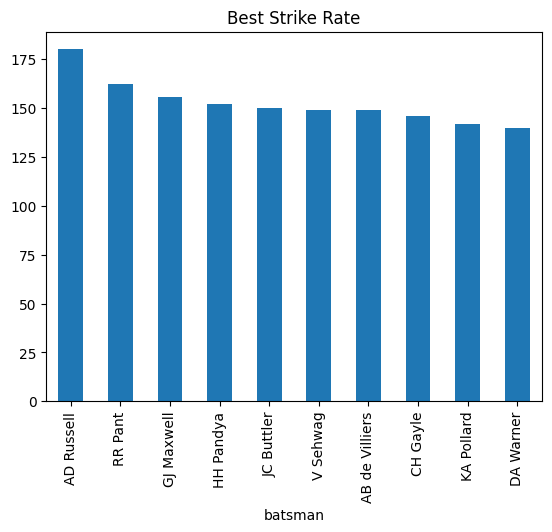

In [15]:
runs = df1.groupby('batsman')['batsman_runs'].sum()
balls = df1.groupby('batsman')['ball'].count()

sr = (runs / balls) * 100

batsman_stats = pd.DataFrame({
    'runs': runs,
    'balls': balls,
    'strike_rate': sr
})

# filter
batsman_stats = batsman_stats[batsman_stats['runs'] >= 1000]

top_sr = batsman_stats.sort_values(by='strike_rate', ascending=False).head(10)

print(top_sr)

top_sr['strike_rate'].plot(kind='bar', title='Best Strike Rate')
plt.show()

**9. Which bowler has best economy (min overs bowled)?**

**Logic:**

total runs conceded

total balls → convert to overs

economy = runs / overs

                  runs       overs   economy
bowler                                      
A Kumble          1089  163.833333  6.646999
DW Steyn          2454  367.833333  6.671500
GD McGrath         366   54.833333  6.674772
M Muralitharan    1765  263.500000  6.698292
R Ashwin          3391  502.666667  6.746021
RD Chahar          376   55.500000  6.774775
SP Narine         2939  433.333333  6.782308
RE van der Merwe   515   75.833333  6.791209
Rashid Khan       1257  184.333333  6.819168
DL Vettori         894  130.833333  6.833121


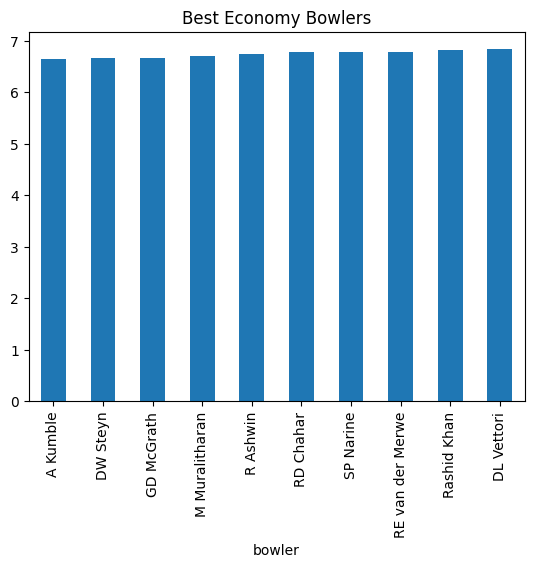

In [16]:
runs_conceded = df1.groupby('bowler')['total_runs'].sum()
balls_bowled = df1.groupby('bowler')['ball'].count()

overs = balls_bowled / 6

economy = runs_conceded / overs

bowler_stats = pd.DataFrame({
    'runs': runs_conceded,
    'overs': overs,
    'economy': economy
})

# filter (min 50 overs)
bowler_stats = bowler_stats[bowler_stats['overs'] >= 50]

top_economy = bowler_stats.sort_values(by='economy').head(10)

print(top_economy)

top_economy['economy'].plot(kind='bar', title='Best Economy Bowlers')
plt.show()

**10. Which team is best at chasing?**

**Logic:**

Teams winning by wickets = chasing success

winner
Kolkata Knight Riders          46
Mumbai Indians                 44
Royal Challengers Bangalore    42
Delhi Daredevils               41
Rajasthan Royals               38
Kings XI Punjab                36
Chennai Super Kings            33
Sunrisers Hyderabad            18
Gujarat Lions                  12
Deccan Chargers                11
Name: count, dtype: int64


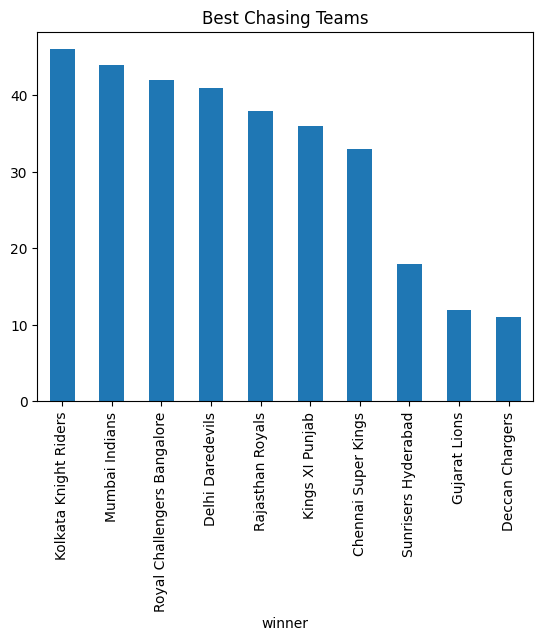

In [17]:
chasing_wins = df[df['win_by_wickets'] > 0]

best_chasing = chasing_wins['winner'].value_counts().head(10)

print(best_chasing)

best_chasing.plot(kind='bar', title='Best Chasing Teams')
plt.show()